# TinyBench — Semantic Components Explorer

Visualise the EBM shape functions, feature importances, and metadata generated by `generate_semantic_components.py` for any benchmark instance.

In [1]:
import gzip, json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

# Vendor path for graph_to_text
_VENDOR = Path("../vendor/intelligible-ai/src")
if str(_VENDOR) not in sys.path:
    sys.path.insert(0, str(_VENDOR))
sys.path.insert(0, str(Path("../src")))

from intelligible_ai.surprise_finder.grapher import EBMGraph, extract_graph, graph_to_text

# ── Global style (matches results_analysis notebook) ──────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

INSTANCES_DIR = Path("../data/instances")
print("Instances dir:", INSTANCES_DIR.resolve())

Instances dir: /Users/aaronalvarez/Desktop/projects/intelligible/tinyBench/data/instances


In [2]:
# ── List all instances that have semantic components ──────────────────────
SEMANTIC_FILES = ["graphs.json.gz", "feature_metadata.json", "semantic_metadata.json"]

all_instances = []
for manifest in sorted(INSTANCES_DIR.glob("**/manifest.json")):
    d = manifest.parent
    if all((d / f).exists() for f in SEMANTIC_FILES):
        parts = d.relative_to(INSTANCES_DIR).parts  # (dataset, seed_N, injector)
        all_instances.append({
            "path": d,
            "dataset": parts[0],
            "seed": parts[1],
            "injector": parts[2],
            "label": "/".join(parts),
        })

print(f"Found {len(all_instances)} instances with semantic components:\n")
for i, inst in enumerate(all_instances):
    print(f"  [{i:2d}]  {inst['label']}")

Found 49 instances with semantic components:

  [ 0]  bike_sharing_100/seed_42/anomaly_data_quality_filter
  [ 1]  bike_sharing_100/seed_42/anomaly_data_quality_filter_v1
  [ 2]  bike_sharing_100/seed_42/anomaly_riskier_group
  [ 3]  bike_sharing_100/seed_42/fi_leakage_topk
  [ 4]  bike_sharing_100/seed_42/rca_performance_improve
  [ 5]  bike_sharing_100/seed_42/rca_retrain_point
  [ 6]  bike_sharing_1000/seed_42/anomaly_data_quality_filter
  [ 7]  bike_sharing_1000/seed_42/anomaly_data_quality_filter_v1
  [ 8]  bike_sharing_1000/seed_42/anomaly_riskier_group
  [ 9]  bike_sharing_1000/seed_42/fi_leakage_topk
  [10]  bike_sharing_1000/seed_42/rca_retrain_point
  [11]  bike_sharing_10000/seed_42/anomaly_data_quality_filter
  [12]  bike_sharing_10000/seed_42/anomaly_data_quality_filter_v1
  [13]  bike_sharing_10000/seed_42/anomaly_riskier_group
  [14]  bike_sharing_10000/seed_42/fi_leakage_topk
  [15]  bike_sharing_10000/seed_42/rca_performance_improve
  [16]  bike_sharing_500/seed_42/ano

In [3]:
# ── Select an instance by index from the list above ───────────────────────
INSTANCE_IDX = 0   # <-- change this

instance = all_instances[INSTANCE_IDX]
instance_dir = instance["path"]
print(f"Selected: {instance['label']}")
print(f"Path:     {instance_dir}")

Selected: bike_sharing_100/seed_42/anomaly_data_quality_filter
Path:     ../data/instances/bike_sharing_100/seed_42/anomaly_data_quality_filter


In [4]:
# ── Load all semantic component files ─────────────────────────────────────
with open(instance_dir / "semantic_metadata.json") as f:
    sem_meta = json.load(f)

with open(instance_dir / "feature_metadata.json") as f:
    feat_meta = json.load(f)

with gzip.open(instance_dir / "graphs.json.gz", "rt", encoding="utf-8") as f:
    graphs_data = json.load(f)

umap_path = instance_dir / "umap_embedding.json"
umap_data = json.loads(umap_path.read_text()) if umap_path.exists() else {}

table = pd.read_csv(instance_dir / "table.csv")
with open(instance_dir / "manifest.json") as f:
    manifest = json.load(f)

# Sort features by importance descending
sorted_feats = sorted(feat_meta.items(), key=lambda kv: kv[1].get("importance", 0), reverse=True)

print(f"Target:    {sem_meta['target']}")
print(f"Rows:      {sem_meta['n_rows']}")
print(f"Features:  {sem_meta['n_features']}")
print(f"Injector:  {manifest['phenomenon']['injector_type']}")
print(f"Computed in {sem_meta.get('compute_duration_seconds', '?')}s")

Target:    cnt
Rows:      100
Features:  17
Injector:  anomaly_data_quality_filter
Computed in 33.87s


---
## 1 — Feature Importances

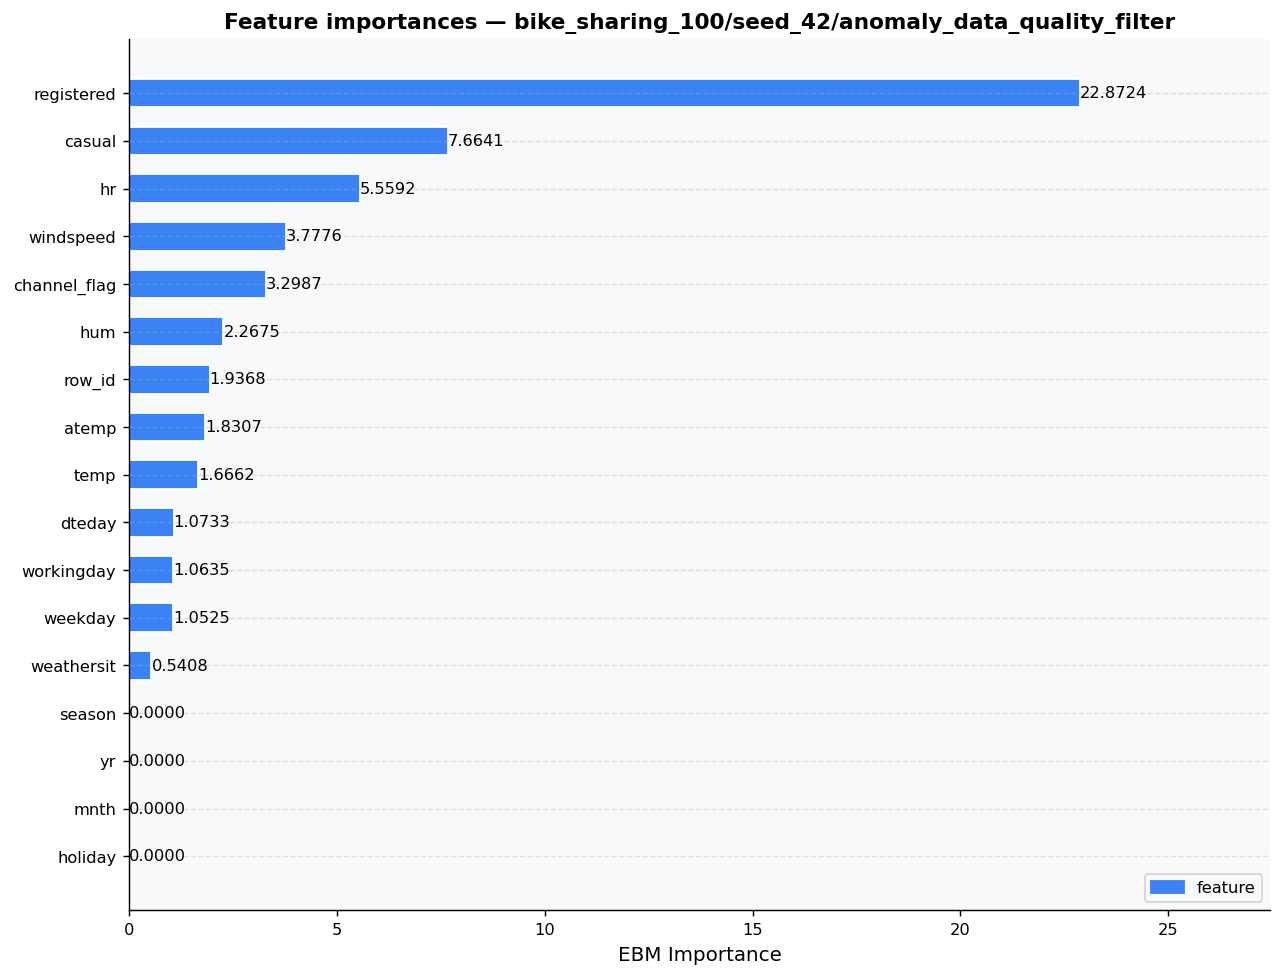

In [5]:
names = [k for k, _ in sorted_feats]
importances = [v.get("importance", 0) for _, v in sorted_feats]

# Colour the order_col / target differently so it stands out
order_col = manifest["phenomenon"]["params"].get("order_col", "")
target_col = sem_meta["target"]

def bar_color(name):
    if name == order_col:
        return "#f97316"   # orange — order/time column
    return "#3b82f6"       # blue — regular feature

colors = [bar_color(n) for n in names]

fig, ax = plt.subplots(figsize=(10, max(3, len(names) * 0.45)))
bars = ax.barh(names[::-1], importances[::-1], color=colors[::-1], height=0.6, edgecolor="white")

for bar, v in zip(bars, importances[::-1]):
    ax.text(v + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", fontsize=9)

ax.set_xlabel("EBM Importance")
ax.set_title(f"Feature importances — {instance['label']}")
ax.set_xlim(0, max(importances) * 1.2)

# Legend
from matplotlib.patches import Patch
legend_entries = [Patch(color="#3b82f6", label="feature")]
if order_col:
    legend_entries.append(Patch(color="#f97316", label=f"order_col ({order_col})"))
ax.legend(handles=legend_entries, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

---
## 2 — EBM Shape Functions

Each chart is one feature's learned contribution to predictions. Y-axis = additive contribution (log-odds for classification, target units for regression). Shaded band = 95% confidence interval.

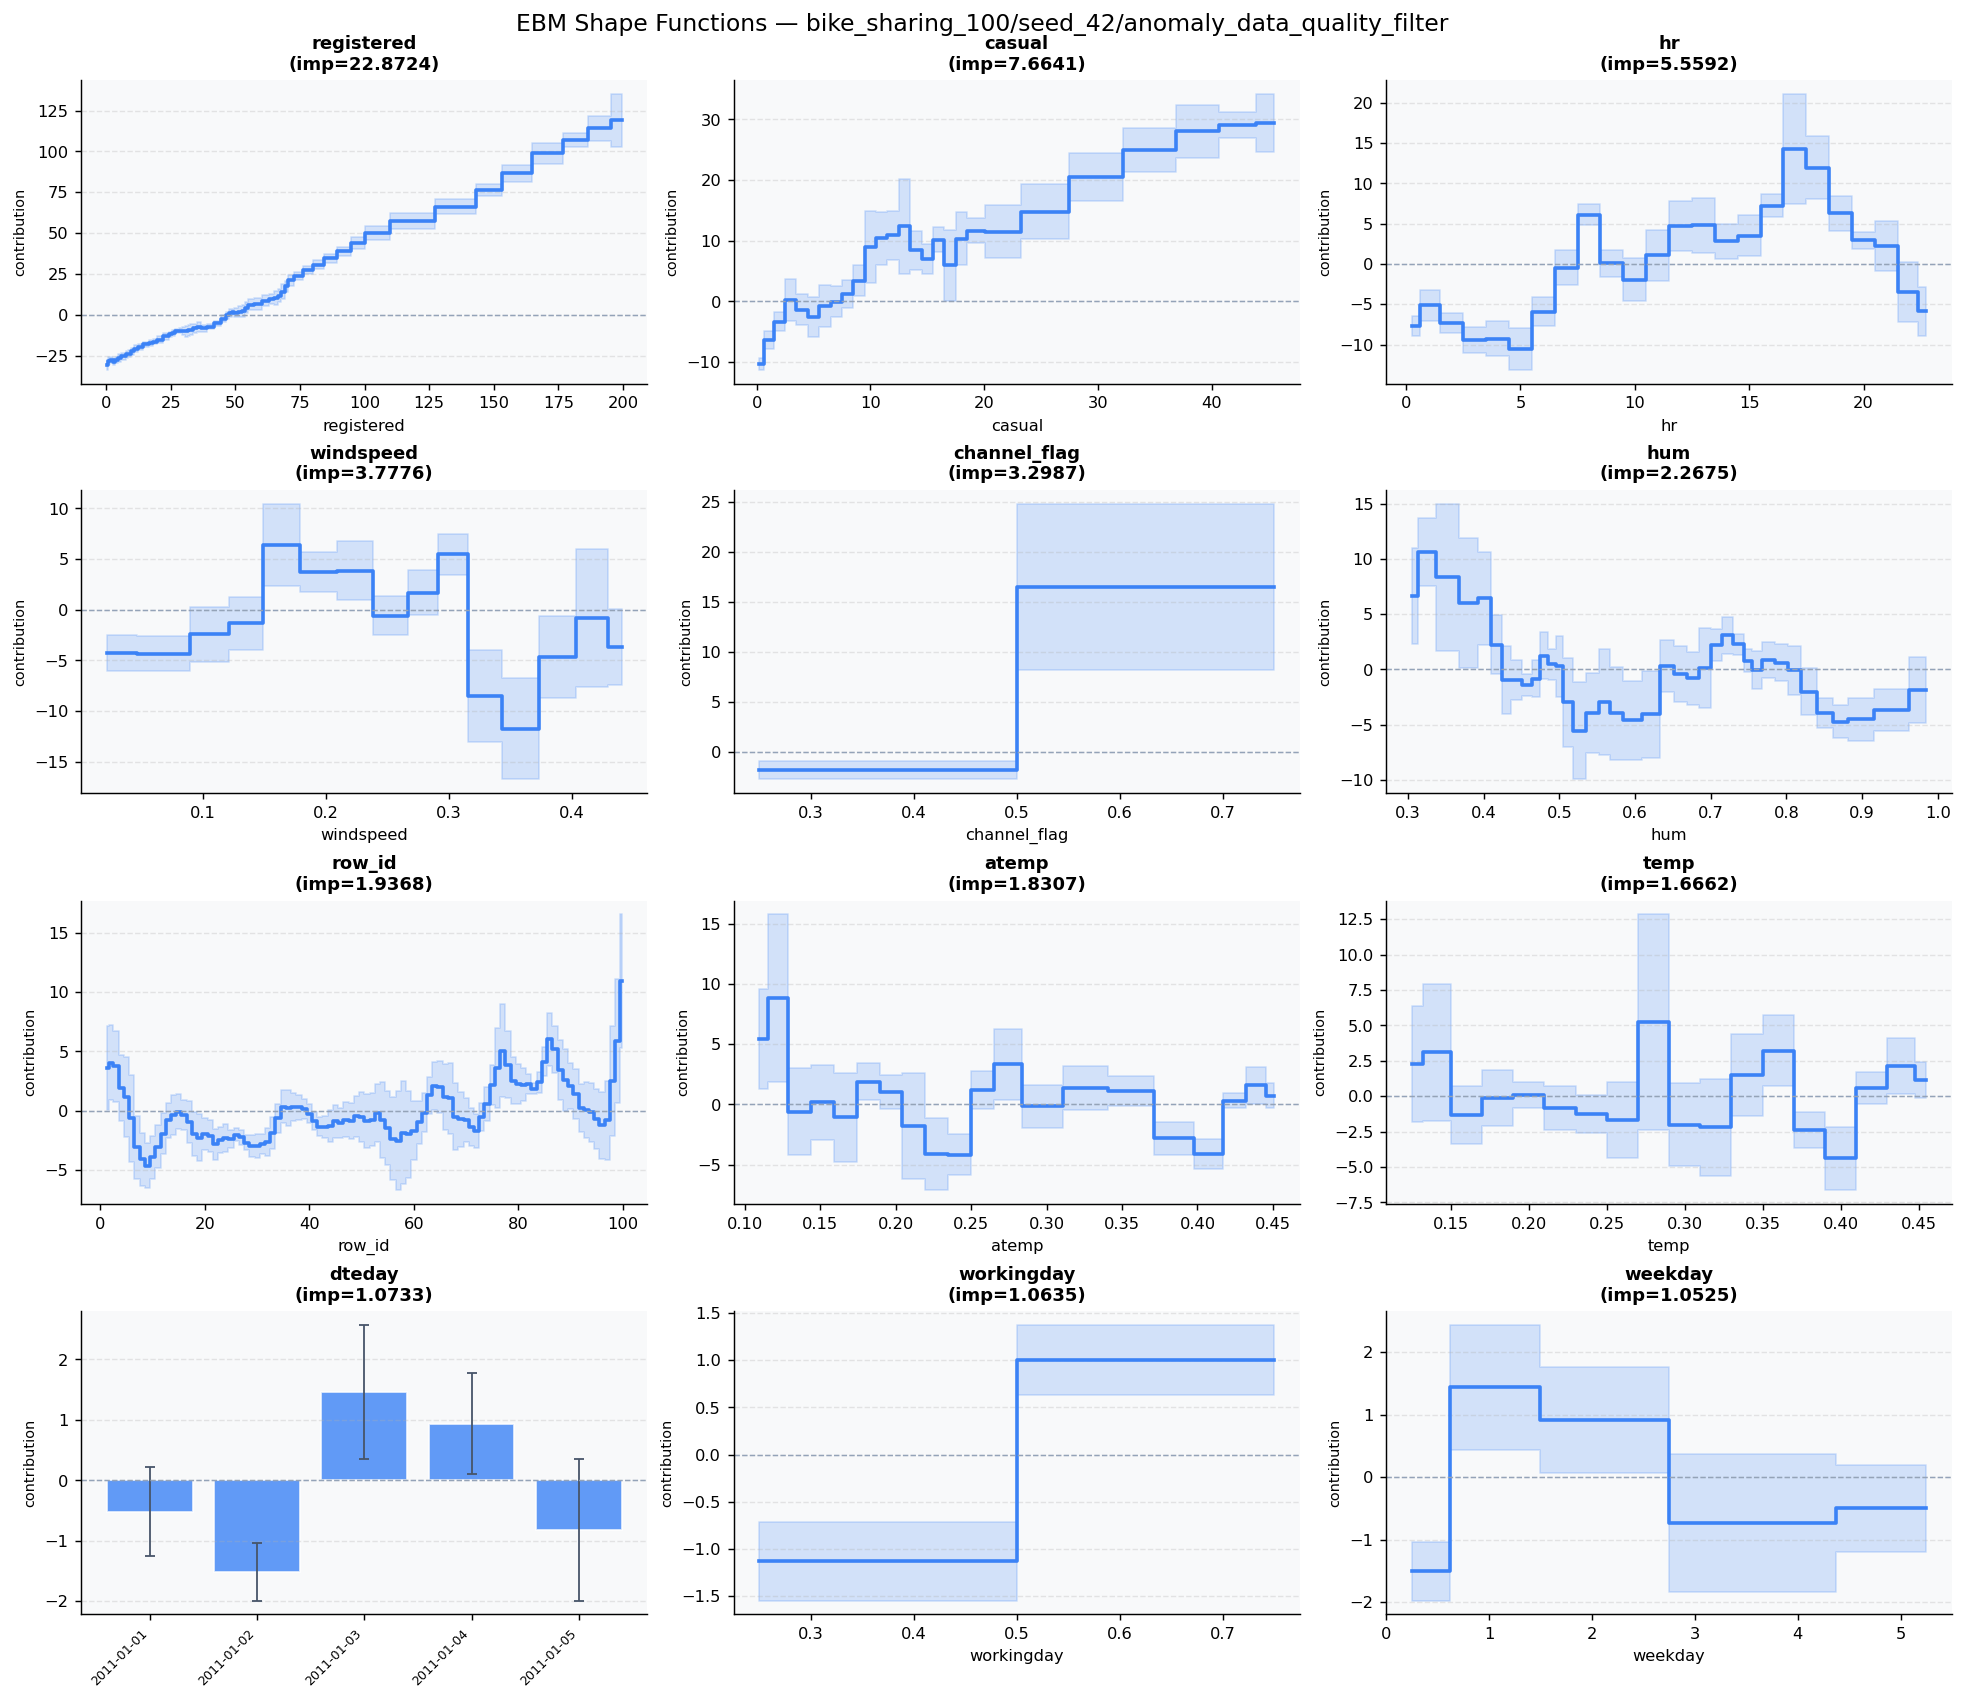

In [6]:
N_SHAPES = 12   # <-- how many top features to plot (change as needed)

main_effects = graphs_data["main_effects"]

# Only features that have valid graph data
valid_feats = [
    (name, info)
    for name, info in sorted_feats
    if name in main_effects and "error" not in main_effects[name]
][:N_SHAPES]

if not valid_feats:
    print("No valid shape functions found.")
else:
    ncols = 3
    nrows = -(-len(valid_feats) // ncols)   # ceiling division
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 5, nrows * 3.2),
                             constrained_layout=True)
    axes_flat = axes.flat if nrows > 1 or ncols > 1 else [axes]

    for ax, (fname, finfo) in zip(axes_flat, valid_feats):
        entry = main_effects[fname]
        scores = np.array(entry["scores"])
        lower  = np.array(entry["lower"])
        upper  = np.array(entry["upper"])
        feat_type = entry["feature_type"]
        imp = finfo.get("importance", 0)
        color = "#f97316" if fname == order_col else "#3b82f6"

        if feat_type == "continuous":
            # Use bin midpoints for x
            bins = entry["x_vals"]   # list of [lo, hi]
            midpoints = [(lo + hi) / 2 for lo, hi in bins]
            ax.step(midpoints, scores, where="mid", color=color, linewidth=2)
            ax.fill_between(midpoints, lower, upper, alpha=0.2, color=color, step="mid")
            ax.axhline(0, color="#94a3b8", linewidth=0.8, linestyle="--")
            ax.set_xlabel(fname, fontsize=9)
        else:
            # Categorical: bar chart
            x_vals = entry["x_vals"]
            x_pos = np.arange(len(x_vals))
            ax.bar(x_pos, scores, color=color, alpha=0.8, edgecolor="white")
            ax.errorbar(x_pos, scores,
                        yerr=[scores - lower, upper - scores],
                        fmt="none", color="#475569", capsize=3, linewidth=1)
            ax.axhline(0, color="#94a3b8", linewidth=0.8, linestyle="--")
            ax.set_xticks(x_pos)
            ax.set_xticklabels(
                [str(v)[:10] for v in x_vals],
                rotation=45, ha="right", fontsize=7
            )

        ax.set_title(f"{fname}\n(imp={imp:.4f})", fontsize=10)
        ax.set_ylabel("contribution", fontsize=8)
        ax.grid(axis="y", alpha=0.3)
        ax.grid(axis="x", alpha=0)

    # Hide unused axes
    for ax in list(axes_flat)[len(valid_feats):]:
        ax.set_visible(False)

    fig.suptitle(f"EBM Shape Functions — {instance['label']}", fontsize=13, y=1.01)
    plt.show()

---
## 3 — EBM Interaction Terms

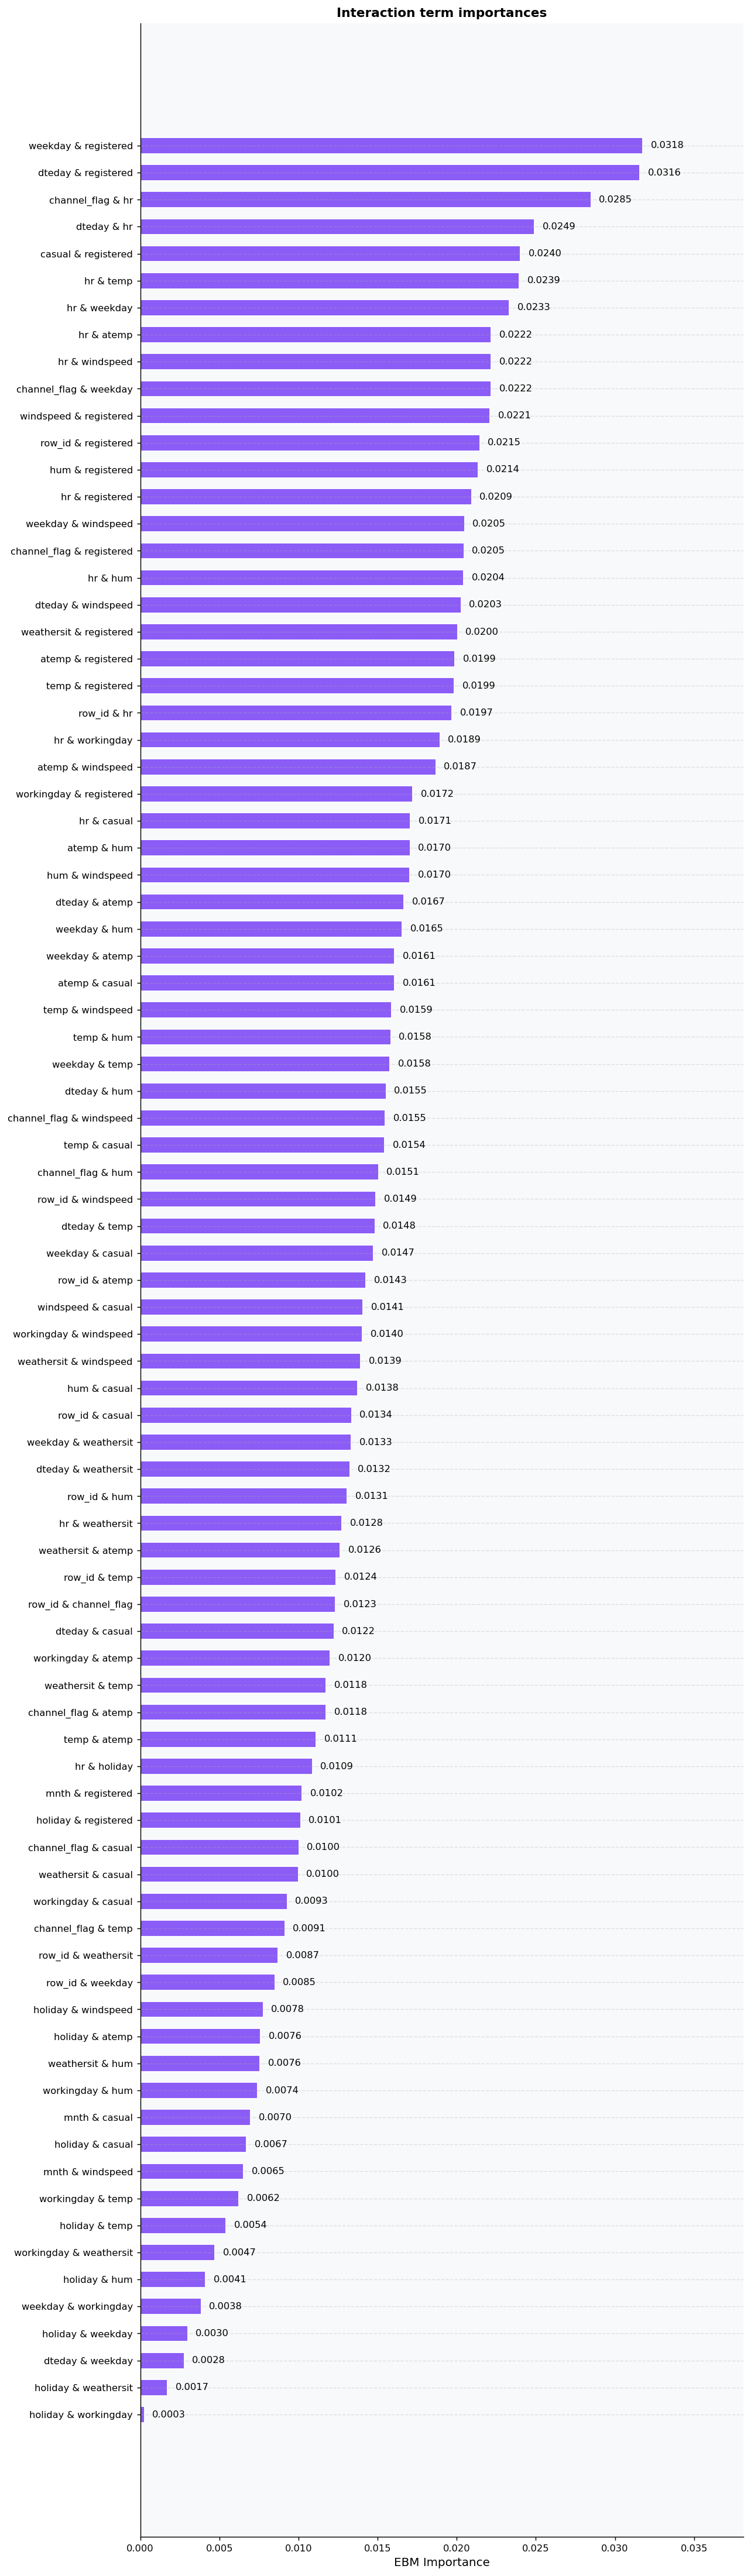

In [7]:
interactions = graphs_data.get("interactions", [])

if not interactions:
    print("No interaction terms found.")
else:
    interactions_sorted = sorted(interactions, key=lambda x: x["importance"], reverse=True)
    labels = [" & ".join(i["features"]) for i in interactions_sorted]
    imps   = [i["importance"] for i in interactions_sorted]

    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.4)))
    bars = ax.barh(labels[::-1], imps[::-1], color="#8b5cf6", height=0.6, edgecolor="white")
    for bar, v in zip(bars, imps[::-1]):
        ax.text(v + 0.0005, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.set_xlabel("EBM Importance")
    ax.set_title("Interaction term importances")
    ax.set_xlim(0, max(imps) * 1.2 if imps else 0.1)
    plt.tight_layout()
    plt.show()

---
## 4 — Feature Metadata & Descriptions

In [8]:
rows = []
for fname, info in sorted_feats:
    rows.append({
        "feature":     fname,
        "importance":  round(info.get("importance", 0), 4),
        "dtype":       info.get("dtype", ""),
        "n_unique":    info.get("n_unique", ""),
        "min":         info.get("min", ""),
        "max":         info.get("max", ""),
        "mean":        info.get("mean", ""),
        "description": info.get("description", "(no description)"),
    })

meta_df = pd.DataFrame(rows)

# Display with descriptions wrapped
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 50)
display(meta_df)

,feature,importance,dtype,n_unique,min,max,mean,description
0,registered,22.8724,int64,63,0.0,202.0,43.38,"The number of registered users or occurrences, varying widely across the dat..."
1,casual,7.6641,int64,27,0.0,47.0,6.94,"The count of casual users or occurrences, varying across the dataset."
2,hr,5.5592,int64,24,0.0,23.0,11.24,"The hour of the day when the observation was made, ranging from 0 to 23."
3,windspeed,3.7776,float64,15,0.0,0.4478,0.2,"The wind speed, normalized and presented as a float value within a specific ..."
4,channel_flag,3.2987,int64,2,0.0,1.0,0.1,"Indicates the type of channel (e.g., online or offline) associated with the ..."
5,hum,2.2675,float64,38,0.3,1.0,0.6292,"The humidity level expressed as a float value, ranging from 0 to 1."
6,row_id,1.9368,int64,100,1.0,100.0,50.5,A unique identifier for each row in the dataset.
7,atemp,1.8307,float64,20,0.1061,0.4545,0.2758,"The normalized 'feels like' temperature, represented as a float value on a s..."
8,temp,1.6662,float64,18,0.12,0.46,0.271,"The normalized temperature, shown as a float value on a specific scale."
9,dteday,1.0733,object,5,,,,"The specific date of the recorded entry, formatted as YYYY-MM-DD."


---
## 5 — UMAP Embedding

*(Empty if `umap-learn` was not installed when semantic components were generated.)*

In [9]:
if not umap_data or "x" not in umap_data:
    print("UMAP embedding not available (umap_embedding.json is empty).")
    print("Install umap-learn and re-run generate_semantic_components.py --force to populate it.")
else:
    x = np.array(umap_data["x"])
    y = np.array(umap_data["y"])
    target = np.array(umap_data["target"])

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(x, y, c=target, cmap="viridis", s=12, alpha=0.7, linewidths=0)
    plt.colorbar(sc, ax=ax, label=sem_meta["target"])
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_title(f"UMAP embedding — coloured by {sem_meta['target']}\n{instance['label']}")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

UMAP embedding not available (umap_embedding.json is empty).
Install umap-learn and re-run generate_semantic_components.py --force to populate it.


---
## 6 — LLM Prompt Preview

The exact text that gets injected into the model prompt when `--semantic` is used.

In [10]:
from eval_pipeline import _build_semantic_context

context_text = _build_semantic_context(instance_dir)
print(context_text)

## Semantic Context
Target: cnt | Rows: 100 | Features: 17

Feature Importances (EBM, ranked):
1. registered (22.872) — The number of registered users or occurrences, varying widely across the dataset.. Range 0.0–202.0, mean 43.38, 63 unique values.
2. casual (7.664) — The count of casual users or occurrences, varying across the dataset.. Range 0.0–47.0, mean 6.94, 27 unique values.
3. hr (5.559) — The hour of the day when the observation was made, ranging from 0 to 23.. Range 0.0–23.0, mean 11.24, 24 unique values.
4. windspeed (3.778) — The wind speed, normalized and presented as a float value within a specific range.. Range 0.0–0.4478, mean 0.2, 15 unique values.
5. channel_flag (3.299) — Indicates the type of channel (e.g., online or offline) associated with the entry.. Range 0.0–1.0, mean 0.1, 2 unique values.
6. hum (2.268) — The humidity level expressed as a float value, ranging from 0 to 1.. Range 0.3–1.0, mean 0.6292, 38 unique values.
7. row_id (1.937) — A unique identifier f

---
## 7 — Table Preview

The injected `table.csv` — spot-check the injected values around the change point.

In [11]:
print(f"Shape: {table.shape}")
print(f"Columns: {list(table.columns)}\n")

# If it's a retrain-point instance, show rows around the change point
effects = manifest["phenomenon"]["effects"]
if "change_row_id" in effects and effects["change_row_id"] is not None:
    order_col = manifest["phenomenon"]["params"]["order_col"]
    change_id = effects["change_row_id"]
    # Try to convert to the right type
    try:
        change_id = type(table[order_col].iloc[0])(change_id)
    except Exception:
        pass
    change_idx = table[table[order_col] == change_id].index
    if len(change_idx):
        idx = change_idx[0]
        window = table.iloc[max(0, idx - 5): idx + 6]
        print(f"Change point at {order_col}={change_id} (row index {idx}). Showing ±5 rows:")
        display(window)
    else:
        print(f"Change point {order_col}={change_id} not found in index.")
        display(table.head(10))
else:
    display(table.head(10))

Shape: (100, 18)
Columns: ['row_id', 'channel_flag', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']



,row_id,channel_flag,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,0,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,0,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,0,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,0,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,0,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,0,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,0,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,0,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,0,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14
